In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


In [ ]:
df = pd.read_csv("final_internship_data.csv")
df.shape

(60300, 26)

In [ ]:
summary = []

duplicates = df.duplicated().sum()

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100

    summary.append([
        col,
        df[col].dtype,
        null_count,
        df[col].nunique()])

summary_df = pd.DataFrame(
    summary,
    columns=["Column", "Type", "Missing Values",  "Unique Values"])

print("Number of duplicate rows:", duplicates)

summary_df

Number of duplicate rows: 0


,Column,Type,Missing Values,Unique Values
0,User ID,object,0,60300
1,User Name,object,0,47111
2,Driver Name,object,0,46986
3,Car Condition,object,0,4
4,Weather,object,0,5
5,Traffic Condition,object,0,3
6,key,object,0,3598
7,fare_amount,float64,0,743
8,pickup_datetime,object,0,59187
9,pickup_longitude,float64,0,38138


In [ ]:
df['fare_amount'].value_counts()

#df['Driver Name'].value_counts()

,count
fare_amount,
6.50,2970
4.50,2540
8.50,2317
5.30,1759
6.10,1722
...,...
48.67,1
30.20,1
31.60,1


Data cleaning

In [ ]:
#deleting

columns_to_drop = ['Driver Name', 'User Name', 'key','User ID']
df = df.drop(columns=columns_to_drop)

In [ ]:
# فصل ال target

target = "fare_amount"
y = df[target]
X = df.drop(columns=[target])

####train - test before preproc.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature engineerimg

In [ ]:
#Feature Engineering of time-s


df['Times of day'] = pd.cut(df['hour'],bins=[-1,6,12,18,24],labels=['Night','Morning','Afternoon','Evening'])

df['Peak hours'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

df['IS weekend'] = df["weekday"].isin([4,5,6]).astype(int)


def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['month season'] = df['month'].apply(get_season)

df['distance_hour'] = df['distance'] * df['hour']


df = df.drop('pickup_datetime', axis=1)
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Times of day,Peak hours,IS weekend,month season,distance_hour
0,Very Good,windy,Congested Traffic,4.5,-1.288826,0.710721,-1.288779,0.710563,1.0,17.0,...,14.342611,34.543548,27.572573,1.030764,-2.918897,Afternoon,1,0,Summer,17.522987
1,Excellent,cloudy,Flow Traffic,16.9,-1.291824,0.710546,-1.291182,0.711780,1.0,16.0,...,23.130775,15.125872,8.755732,8.450134,-0.375217,Afternoon,1,0,Winter,135.202138
2,Bad,stormy,Congested Traffic,5.7,-1.291242,0.711418,-1.291391,0.711231,2.0,0.0,...,19.865289,17.722624,9.847344,1.389525,2.599961,Night,0,0,Summer,0.000000
3,Very Good,stormy,Flow Traffic,7.7,-1.291319,0.710927,-1.291396,0.711363,1.0,4.0,...,21.063132,15.738963,7.703421,2.799270,0.133905,Night,0,1,Spring,11.197081
4,Bad,stormy,Congested Traffic,5.3,-1.290987,0.711536,-1.290787,0.711811,1.0,7.0,...,15.219339,23.732406,15.600745,1.999157,-0.502703,Morning,1,0,Spring,13.994098


/tmp/ipykernel_190/3499033500.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


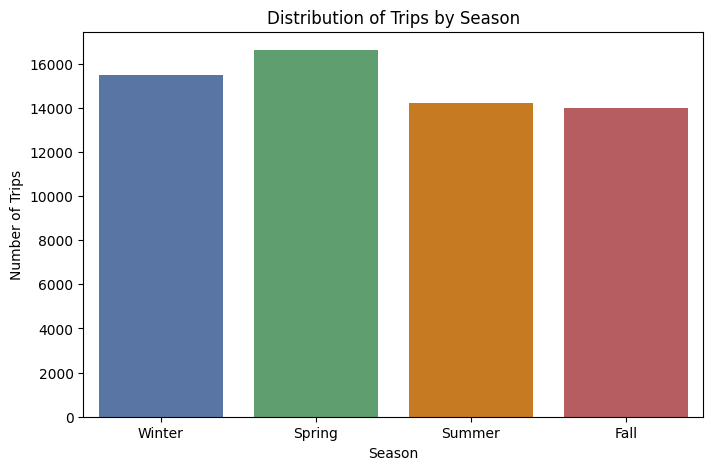

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
order = ['Winter','Spring','Summer','Fall']
sns.countplot(
    x='month season',
    data=df,
    order=order,
    palette=['#4C72B0', '#55A868', '#E17C05', '#C44E52']
)

plt.title("Distribution of Trips by Season")
plt.xlabel("Season")
plt.ylabel("Number of Trips")

plt.show()

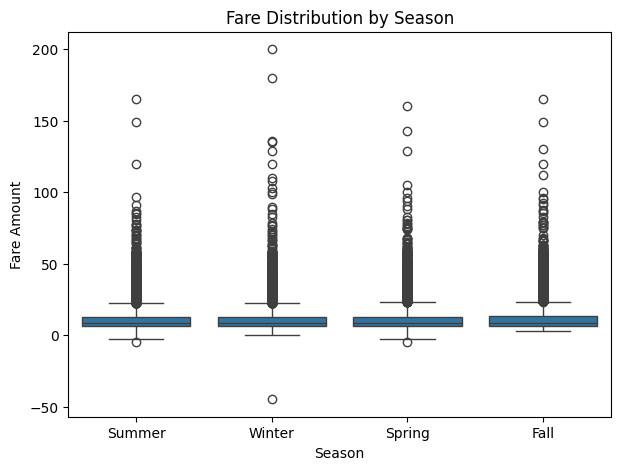

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='month season',
    y='fare_amount',
    data=df
)

plt.title("Fare Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Fare Amount")

plt.show()

##Data cleaning

##OUTLIERS

In [ ]:
numeric_cols = ['fare_amount','distance','passenger_count','bearing','jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers, min={df[col].min()}, max={df[col].max()}")

fare_amount: 5222 outliers, min=-44.9, max=200.0
distance: 5078 outliers, min=0.0, max=8670.149806
passenger_count: 6658 outliers, min=0.0, max=6.0
bearing: 0 outliers, min=-3.141465561, max=3.141592654
jfk_dist: 7134 outliers, min=1.15699468, max=30132.71562
ewr_dist: 3375 outliers, min=1.470598941, max=30167.24136
lga_dist: 2697 outliers, min=0.635375691, max=30166.93337
sol_dist: 2215 outliers, min=2.380477168, max=30159.05348
nyc_dist: 2629 outliers, min=0.240965942, max=30161.93186


In [ ]:
#handeling fare amount

df = df[df['fare_amount'] > 0]
df.loc[df['fare_amount'] < 0, 'fare_amount'] = np.nan
df['fare_amount'] = df['fare_amount'].fillna(df['fare_amount'].median())

In [ ]:
# handling distance
df['distance'] = df['distance'].clip(lower=0.1, upper=100)

# handling passengers
df.loc[df['passenger_count'] == 0, 'passenger_count'] = np.nan
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

# handling airports distance
airport_cols = ['jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']
df[airport_cols] = df[airport_cols].clip(upper=200)

/tmp/ipykernel_190/582073973.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)


In [ ]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,...,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,Peak hours,IS weekend,distance_hour
count,60289.000000,60289.000000,60289.000000,60288.000000,60288.000000,60289.000000,60288.000000,60288.000000,60288.000000,60288.000000,...,60288.000000,60288.000000,60288.000000,60288.000000,60288.000000,60288.000000,60288.000000,60289.000000,60289.000000,60288.000000
mean,11.330249,-1.265675,0.696982,-1.265726,0.696969,1.674086,13.504279,15.662901,6.269805,3.034667,...,45.179928,39.106412,23.300922,22.699669,15.121461,3.474742,0.280285,0.281511,0.436929,236.266164
std,9.647400,0.181067,0.108342,0.180827,0.105003,1.292068,6.506296,8.672053,3.458191,1.953061,...,23.045486,24.095132,26.116898,26.515984,27.605139,5.770128,1.803961,0.449740,0.496010,5137.266593
min,0.010000,-1.316394,-1.291664,-1.477495,-1.291655,1.000000,0.000000,1.000000,1.000000,0.000000,...,1.156995,1.470599,0.635376,2.380477,0.240966,0.100000,-3.141466,0.000000,0.000000,0.000000
25%,6.000000,-1.291405,0.710960,-1.291390,0.710949,1.000000,9.000000,8.000000,3.000000,1.000000,...,41.355635,32.206435,17.093300,14.917222,7.167885,1.218490,-0.867352,0.000000,0.000000,11.953102
50%,8.500000,-1.291227,0.711269,-1.291196,0.711281,1.000000,14.000000,16.000000,6.000000,3.000000,...,42.527960,34.790418,19.573130,18.388747,10.491104,2.114758,-0.075004,0.000000,0.000000,25.443078
75%,12.500000,-1.290972,0.711525,-1.290908,0.711539,2.000000,19.000000,23.000000,9.000000,5.000000,...,43.796556,38.321510,22.174683,22.442990,14.469388,3.875381,2.175506,1.000000,1.000000,51.912861
max,200.000000,0.711806,7.000225,0.712985,0.757738,6.000000,23.000000,31.000000,12.000000,6.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,100.000000,3.141593,1.000000,1.000000,199344.100768


<Axes: xlabel='fare_amount'>

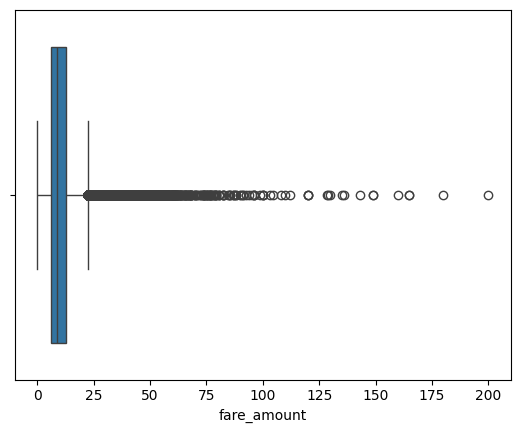

In [ ]:
import seaborn as sns
sns.boxplot(x=df['fare_amount'])

##handeling missing values

In [ ]:

numeric_cols = ['distance', 'bearing', 'dropoff_longitude', 'dropoff_latitude', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']
categorical_cols = ['car condition', 'weather', 'traffic condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

df['fare_amount'] = df['fare_amount'].fillna(df['fare_amount'].median())

df.isnull().sum()

,0
Car Condition,0
Weather,0
Traffic Condition,0
fare_amount,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0
hour,0


##MODELING

In [ ]:
#Linear Regression (One-Hot + Scaling)

lr_categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day', 'month season']
lr_num = ['distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']

X_lr = pd.get_dummies(df[lr_categorical + lr_num], drop_first=True)

# Scaling for numircal
scaler = StandardScaler()
X_lr[lr_num] = scaler.fit_transform(X_lr[lr_num])

#split
y = df['fare_amount']
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y, test_size=0.2, random_state=42)

#training
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

#calculat RMSE
y_pred_lr = lr_model.predict(X_test_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 6.467838102045672


In [ ]:
#Random Forest / XGBoost (Label Encoding للفئات، لا Scaling)

tree_categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day', 'month season']
tree_num = ['distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']

X_tree = df[tree_categorical + tree_num].copy()
for col in tree_categorical:
    le = LabelEncoder()
    X_tree[col] = le.fit_transform(X_tree[col])

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y, test_size=0.2, random_state=42)

In [ ]:
# Random Forest
#training
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_tree, y_train_tree)

#Predictions
y_pred_rf = rf_model.predict(X_test_tree)

# calculat RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 4.690531451390527


In [ ]:
#XGBoost
#training
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_tree, y_train_tree)

# calculat RMSE
y_pred_xgb = xgb_model.predict(X_test_tree)
rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 4.671055805679458


###Evaluation

In [ ]:
#تقييم Linear Regression

y_pred_lr = lr_model.predict(X_test_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
r2_lr = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
RMSE: 6.467838102045672
MAE: 3.397477598528235
R2: 0.5620045741182915


In [ ]:
#تقييم Random Forest

y_pred_rf = rf_model.predict(X_test_tree)

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
mae_rf = mean_absolute_error(y_test_tree, y_pred_rf)
r2_rf = r2_score(y_test_tree, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
RMSE: 4.690531451390527
MAE: 2.0629098808860142
R2: 0.7696461904506495


In [ ]:
#تقييم XGBoost

y_pred_xgb = xgb_model.predict(X_test_tree)

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_tree, y_pred_xgb)
r2_xgb = r2_score(y_test_tree, y_pred_xgb)

print("XGBoost")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost
RMSE: 4.671055805679458
MAE: 1.8653778711621252
R2: 0.7715551320815249


###Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

print(results)

               Model      RMSE       MAE        R2
0  Linear Regression  6.467838  3.397478  0.562005
1      Random Forest  4.690531  2.062910  0.769646
2            XGBoost  4.671056  1.865378  0.771555


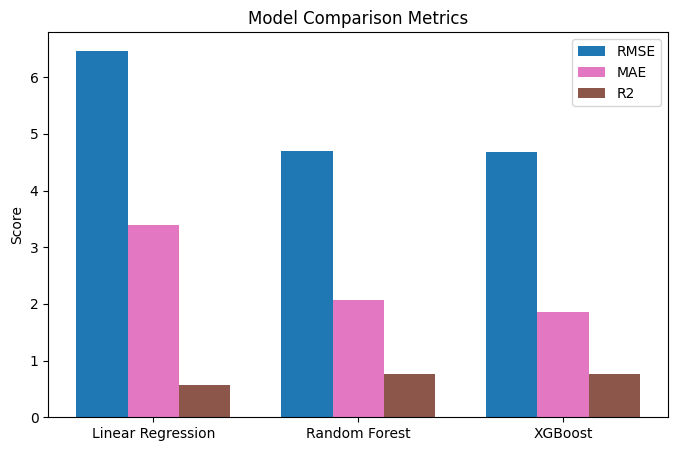

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

models = results['Model']
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, results['RMSE'], width, label='RMSE', color='#1f77b4')
plt.bar(x, results['MAE'], width, label='MAE', color='#e377c2')
plt.bar(x + width, results['R2'], width, label='R2', color='#8c564b')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison Metrics")
plt.legend()
plt.show()

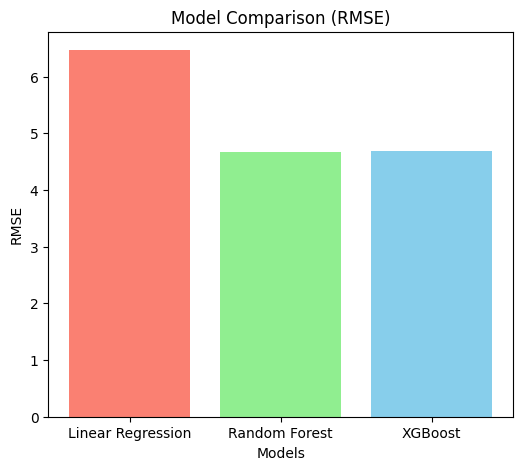

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [rmse_lr, rmse_xgb, rmse_rf]

colors = ['salmon', 'lightgreen', 'skyblue']

plt.figure(figsize=(6,5))
plt.bar(models, rmse_scores, color=colors)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")
plt.show()

##Validation

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf_model,
    X_tree,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rmse_scores = -scores

print("RMSE for each fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

In [ ]:
#to more inhancing

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
#to enhance CV
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    rf_model,
    X_tree,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

rmse_scores = -scores

print("RMSE per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

In [ ]:
#may be a problem

sns.histplot(df['fare_amount'])

### (fare amount) showed a right-skewed distribution so we can use Transformation to improve model stability

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    "n_estimators": [100,200,300,400],
    "max_depth": [10,20,30,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_tree, y_train_tree)

print("Best RF Parameters:", rf_random.best_params_)

In [ ]:
best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_test_tree)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))

print("Tuned Random Forest RMSE:", rmse_rf)

In [ ]:
#xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_dist_xgb = {
    "n_estimators": [200,400,600],
    "max_depth": [3,5,7,10],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_tree, y_train_tree)

print("Best XGB Parameters:", xgb_random.best_params_)

In [ ]:
best_xgb = xgb_random.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_tree)

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))

print("Tuned XGBoost RMSE:", rmse_xgb)

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest Tuned","XGBoost Tuned"],
    "RMSE": [rmse_lr, rmse_xgb, rmse_rf]
})

print(results.sort_values("RMSE"))

import matplotlib.pyplot as plt
colors = ['salmon', 'lightgreen', 'skyblue']

plt.bar(results["Model"], results["RMSE"], color=colors)
plt.title("Model Comparison After Tuning")
plt.ylabel("RMSE")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_tree, y_pred_final))
mae = mean_absolute_error(y_test_tree, y_pred_final)
r2 = r2_score(y_test_tree, y_pred_final)

print("Final RMSE:", rmse)
print("Final MAE:", mae)
print("Final R2:", r2)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

rf_model.fit(X_train_tree, y_train_tree)
importance = rf_model.feature_importances_

feat_imp = pd.Series(importance, index=X_tree.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
#Residual Analysis

residuals = y_test_tree - y_pred_xgb

plt.scatter(y_pred_xgb, residuals, color="Purple")
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.show()

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_tree, y_pred_xgb, alpha=0.3, color="Orange")

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare (XGBoost)")

plt.show()